Comparing iModulons from PRECISE-1K and PRECISE-MG1655

In [1]:
from pymodulon.core import IcaData
from pymodulon.plotting import *
from os import path
import pandas as pd
import re
from Bio.KEGG import REST
from tqdm.notebook import tqdm
from pymodulon.io import *
from pymodulon.compare import *

pd.set_option('display.max_columns', 100, 'display.max_rows', 100)

In [2]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.sans-serif'] = 'Arial'
matplotlib.rcParams['font.family'] = 'sans-serif'
sns.set_style('ticks')
matplotlib.rcParams['text.color'] = '#000000'
matplotlib.rcParams['axes.labelcolor'] = '#000000'
matplotlib.rcParams['xtick.color'] = '#000000'
matplotlib.rcParams['ytick.color'] = '#000000'

In [3]:
ica_data = load_json_model('C:\\Users\\99hee\\precise_mg1655_R1\\data\\p_mg1655\\PRECISE_WT_MG1655_final2.json.gz')
ica_p1k = load_json_model('C:\\Users\\99hee\\precise_mg1655_R1\\data\\precise-1-k-files\\p1k.json.gz')

In [4]:
links,dots = compare_ica(ica_data.M,ica_p1k.M, cutoff = 0.25)

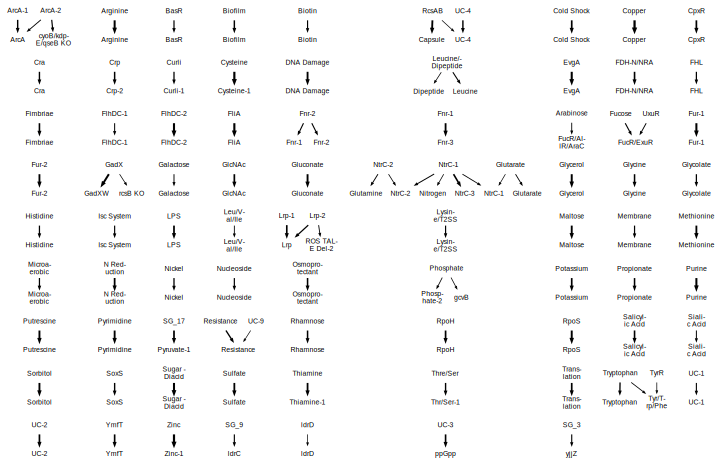

In [5]:
dots

In [6]:
links

[('Maltose', 'Maltose', 0.759277383456158),
 ('Crp', 'Crp-2', 0.6001534276775171),
 ('UC-3', 'ppGpp', 0.6565194400010038),
 ('Glycolate', 'Glycolate', 0.5097242877336536),
 ('RpoS', 'RpoS', 0.7885452574244295),
 ('Translation', 'Translation', 0.6840740408986846),
 ('Fnr-2', 'Fnr-1', 0.4484985870918582),
 ('Fnr-2', 'Fnr-2', 0.4494187716795217),
 ('DNA Damage', 'DNA Damage', 0.7520391167603737),
 ('ArcA-2', 'ArcA', 0.3599148598932741),
 ('ArcA-2', 'cyoB/kdpE/qseB KO', 0.48364325551425463),
 ('SG_3', 'yjjZ', 0.45283975438422613),
 ('RcsAB', 'UC-4', 0.273685767391434),
 ('RcsAB', 'Capsule', 0.7547971530095098),
 ('ArcA-1', 'ArcA', 0.5735461203663698),
 ('Histidine', 'Histidine', 0.5094274649677656),
 ('FliA', 'FliA', 0.8519325670511269),
 ('Tryptophan', 'Tryptophan', 0.5373227809426675),
 ('Tryptophan', 'Tyr/Trp/Phe', 0.32888153521113234),
 ('Membrane', 'Membrane', 0.4883503785885519),
 ('UC-4', 'UC-4', 0.5763548703675476),
 ('N Reduction', 'N Reduction', 0.7103935268265187),
 ('Fur-1', 'F

In [8]:
# #adding matched iMs to a new column 'matched_P1K_iM', along with correlation in column 'P1K_corr' in iModulon table
# ica_data.imodulon_table['matched_P1K_iM'] = [[] for _ in range(len(ica_data.imodulon_table))]
# ica_data.imodulon_table['P1K_corr'] = [[] for _ in range(len(ica_data.imodulon_table))]

# for idx, row in ica_data.imodulon_table.iterrows():
#     for el in links:
#         if el[0] == idx:
#             ica_data.imodulon_table.loc[idx, 'matched_P1K_iM'].append(el[1])
#             ica_data.imodulon_table.loc[idx, 'P1K_corr'].append(el[2])

In [9]:
ica_data.imodulon_table

,regulator,pvalue,qvalue,precision,recall,f1score,TP,regulon_size,imodulon_size,n_regs,functional_category,single_gene_dominant_technical,tcs,trn_enrich_max_regs,regulon_discovery,single_gene,trn_enrich_evidence,compute_regulon_evidence,system_category,matched_P1K_iM,trn_enrich_method,enrichment_category,note,explained_variance,P1K_corr,ko
Maltose,MalT,1.548011e-23,5.539403e-19,0.800000,1.000000,0.888889,8.0,8.0,10,1.0,carbon metabolism,False,False,2.0,False,NaN,"[1,2]",NaN,metabolism,['Maltose'],and,regulatory,NaN,0.006331,[0.7592773834561578],False
Crp,Crp+RpoD,2.159708e-15,3.867820e-11,0.562500,0.076923,0.135338,18.0,234.0,32,2.0,carbon metabolism,False,False,2.0,False,NaN,"[1,2]",NaN,metabolism,['Crp-2'],and,regulatory,NaN,0.018146,[0.6001534276775139],False
UC-3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,NaN,unknown,False,False,NaN,False,NaN,NaN,NaN,unknown,['ppGpp'],NaN,uncharacterized,regulators may include ppGpp,0.026604,[0.6565194400010016],False
Glycolate,RpoD+IHF+ArcA+PdhR+GlcC,0.000000e+00,NaN,1.000000,1.000000,1.000000,6.0,6.0,6,5.0,carbon metabolism,False,False,NaN,False,NaN,NaN,"[0,1,2]",metabolism,['Glycolate'],NaN,regulatory,NaN,0.002824,[0.5097242877336562],False
RpoS,RpoS,8.636316e-19,3.093269e-14,0.305085,0.155172,0.205714,36.0,232.0,118,1.0,global stress,False,False,2.0,False,NaN,"[1,2]",NaN,stress response,['RpoS'],and,regulatory,NaN,0.079112,[0.7885452574244295],False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Resistance,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31,NaN,envelope stress,False,False,NaN,False,NaN,NaN,NaN,stress response,['Resistance'],NaN,biological,NaN,0.008104,[0.5469923833977699],False
NtrC-2,NtrC+RpoN,2.799169e-11,1.001766e-06,0.625000,0.294118,0.400000,5.0,17.0,8,2.0,nitrogen metabolism,False,False,2.0,False,NaN,"[1,2]",NaN,metabolism,"['Glutamine', 'NtrC-2']",and,regulatory,NaN,0.005735,"[0.3781260344184617, 0.3099997996944854]",False
ldrD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8,NaN,unknown,False,False,NaN,False,NaN,NaN,NaN,stress response,['ldrD'],NaN,biological,NaN,0.006436,[0.2883520412450468],False
SG_22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,single_gene,True,False,NaN,False,True,NaN,NaN,single_gene,[],NaN,technical,NaN,0.002188,[],False
